In [2]:
# In this notebook I will work on model that train to remove rain drops from frames, In same way I will use Unet architecture but this time simpler

In [3]:
import numpy as np
# importing libraries
import torch
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from torch import nn
from PIL import Image
import pathlib
from torchsummary import summary
from matplotlib import pyplot as plt
import random
import torch.nn.functional as F
from triton.knobs import nvidia_knobs


##### Handling dataset: all_rain_conditions

In [ ]:
models_path = pathlib.Path("../models")

NameError: name 'pathlib' is not defined

In [4]:
root_path = pathlib.Path("../datasets")
dataset_path = root_path / "all_weather_conditions"

In [5]:
data_list = list(dataset_path.glob("*/data/*"))
gt_list = list(dataset_path.glob("*/gt/*"))

len(data_list), len(gt_list)

(6619, 6617)

In [6]:
## Splitting Datasets
random.shuffle(data_list)

train_idx = int(len(data_list) * 0.7)
train_samples, tmp = data_list[:train_idx], data_list[train_idx:]

test_idx = int(len(tmp) * 0.7)
test_samples, val_samples = tmp[:test_idx], tmp[test_idx:]

len(train_samples), len(test_samples), len(val_samples)

(4633, 1390, 596)

In [7]:
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

In [8]:
TASKS = ['rain', 'night_glare', 'night', 'fog', 'rain_obstructed']
TASK2ID = {t: i for i, t in enumerate(TASKS)}

In [9]:
class DatasetPaired(Dataset):
    def __init__(self, data_list: list, training: bool):
        super().__init__()
        self.data_list = data_list
        self.training = training
        self.samples = [s for s in self.data_list if s.suffix.lower() in [".png"]]

        self.base_tf = transforms.Compose([
            transforms.Resize(size=(256, 256)),
            transforms.ToTensor()
        ])

        self.aug_tf = transforms.Compose([
            transforms.RandomHorizontalFlip(),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        label = sample.parent.parent.stem

        parent_path = dataset_path / label
        data_path = parent_path / "data"
        gt_path = parent_path / "gt"

        img_data = Image.open(data_path / sample.name).convert("RGB")
        img_gt = Image.open(gt_path / sample.name.replace("_rain", "_clean").replace("_exported", "")).convert("RGB")

        # unified augment
        if self.training:
            seed = torch.randint(0, 999999, (1,)).item()
            random.seed(seed)
            torch.manual_seed(seed)
            img_data = self.aug_tf(img_data)

            random.seed(seed)
            torch.manual_seed(seed)
            img_gt = self.aug_tf(img_gt)

        img_data = self.base_tf(img_data)
        img_gt = self.base_tf(img_gt)
        return img_data, img_gt, TASK2ID[label]


In [10]:
training_dataset = DatasetPaired(data_list=train_samples,
                                 training=False)

test_dataset = DatasetPaired(data_list=test_samples,
                             training=False)

val_dataset = DatasetPaired(data_list=val_samples,
                            training=False)
len(training_dataset), len(test_dataset), len(val_dataset)

(4630, 1390, 595)

#### Dataloader

In [11]:
training_data = DataLoader(dataset=training_dataset,
                           batch_size=8,
                           shuffle=True)

test_data = DataLoader(dataset=test_dataset,
                       shuffle=False)

val_data = DataLoader(dataset=val_dataset,
                      shuffle=False)

len(training_data), len(test_data), len(val_data)

(579, 1390, 595)

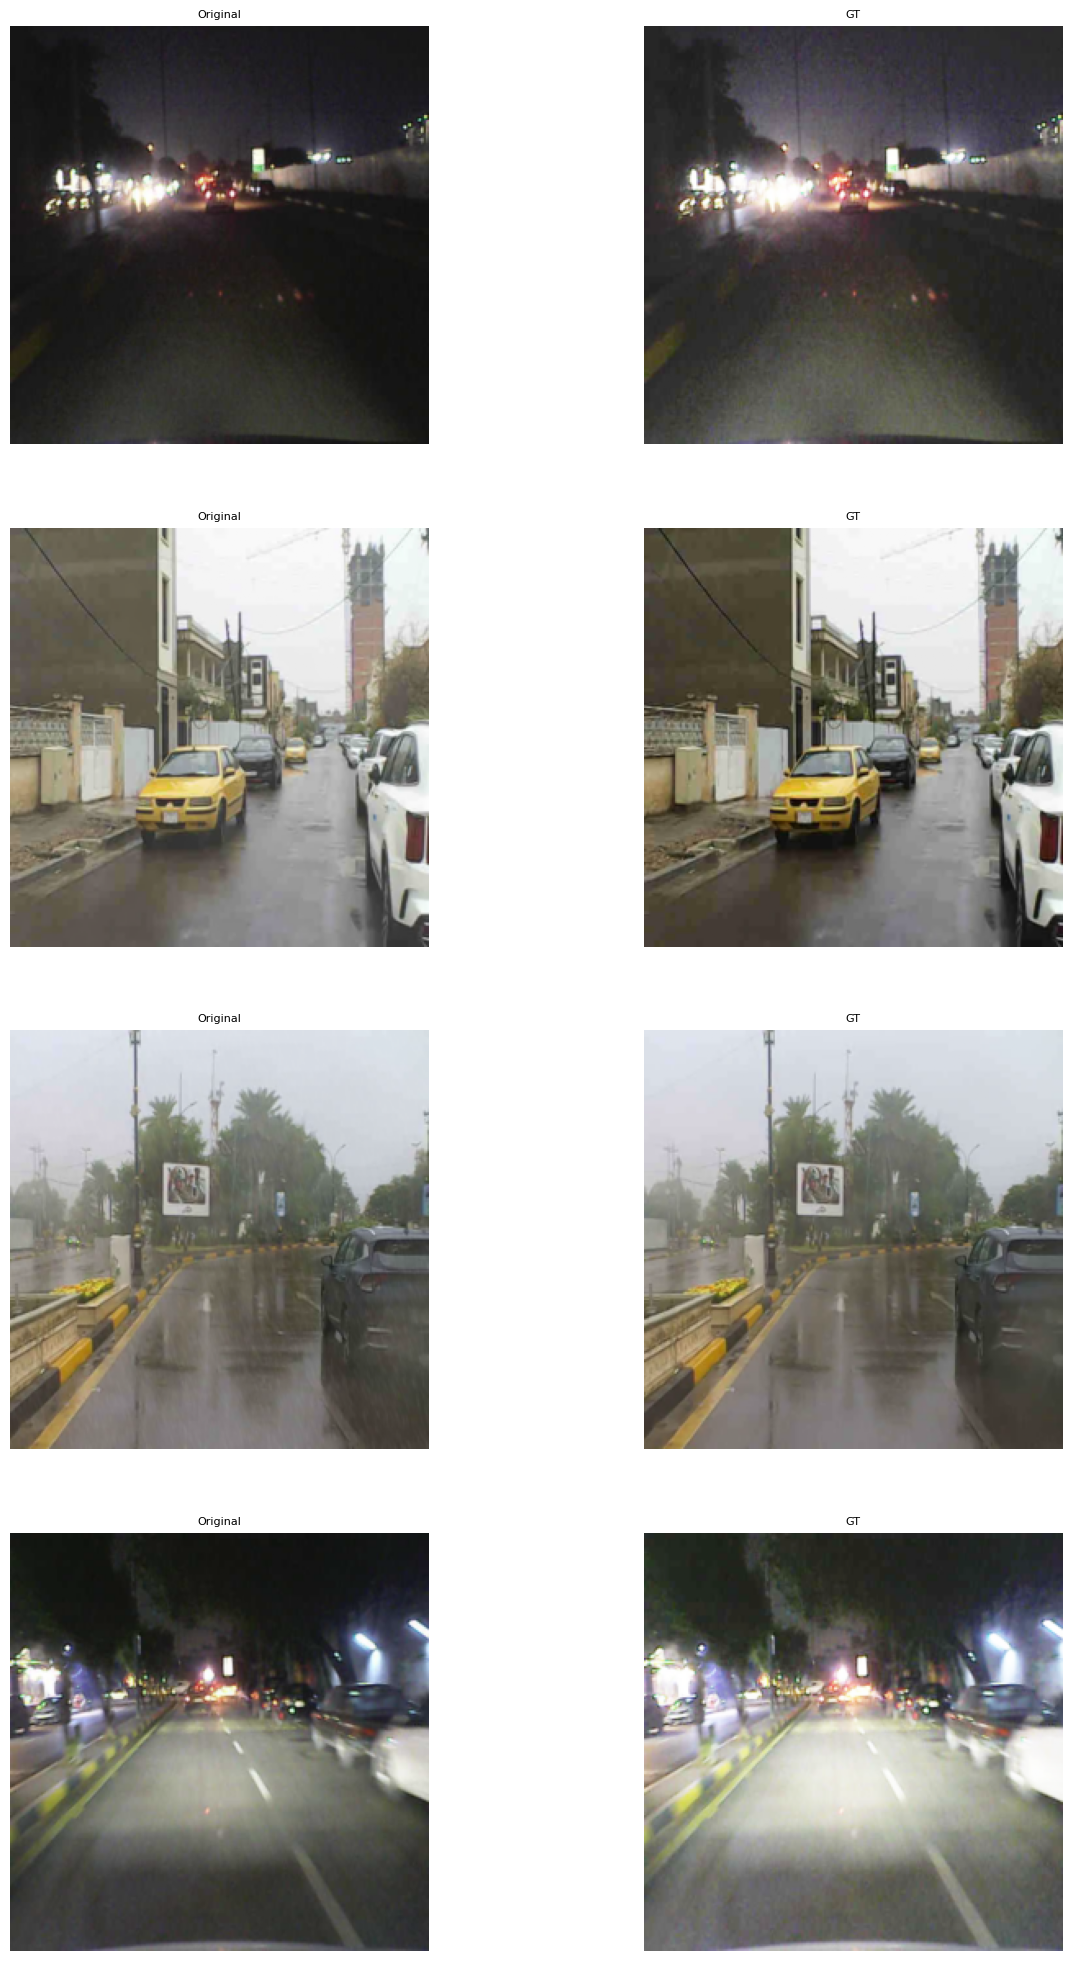

In [12]:
def display_samples(dataset=training_dataset,
                    n=4):
    random_samples = random.choices(dataset, k=n)
    fig, axes = plt.subplots(n, 2, figsize=(15, 25))

    for sample, row in zip(random_samples, axes):
        gt_img = sample[1]
        gt_img = gt_img.permute(1, 2, 0)

        tf_img = sample[0]
        tf_img = tf_img.permute(1, 2, 0)
        row[0].imshow(tf_img)
        row[0].axis(False)
        row[0].set_title(f"Original", fontsize=8)

        row[1].imshow(gt_img)
        row[1].axis(False)
        row[1].set_title(f"GT", fontsize=8)


display_samples(dataset=training_dataset, n=4)

Here there is an issue which is we are lossing some of edges and texture in Traditional Unet Architecure because MaxPool2d is lossing high frequancies resulting in less edges detailed frames:

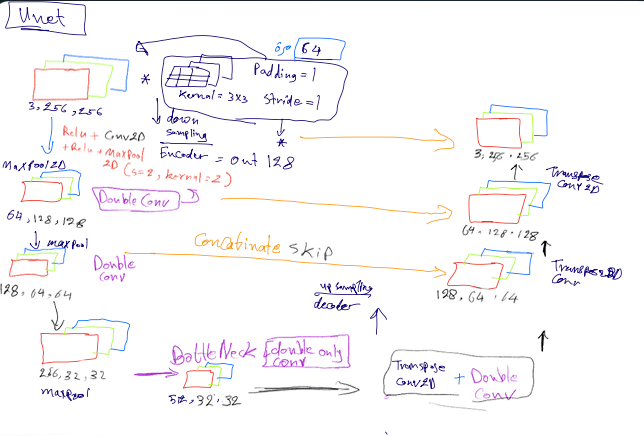

So I will try use wavelet in full Unet Architecture to keep output image sharpen and having details:


First: I need to build Discreet Wavelet Transform [DWT] resulting --> 4 Ch --> LL, LH(Horizontal), HL (Vertical) , HH(Diagonal)  [This will be used inside Encoder instead of MaxPool2d]

Second: I need to create Inverse Discreet Wavelet Transform [IDWT] resulting on spatial image [This will be used inside Decoder]:

References:

1- MWCNN – Multi-Level Wavelet CNN https://openaccess.thecvf.com/content_cvpr_2018/papers/Liu_Multi-Level_Wavelet-CNN_for_CVPR_2018_CVPR_2018_paper.pdf

2- Wavelet U-Net https://arxiv.org/pdf/1901.10889.pdf

3- Wavelet Domain Deep CNN for Image Restoration, 2019. https://arxiv.org/pdf/1902.07373.pdf

4- Wavelet + Deep Learning Survey: “Wavelet-based Deep Learning: A Systematic Review”, 2020.PDF:https://arxiv.org/pdf/2001.00083.pdf

5- DWT / IDWT Basics: PyWavelets Documentation: PyWavelets Official Docs – Discrete Wavelet Transform (2D).https://pywavelets.readthedocs.io/en/latest/ref/dwt-discrete-wavelet-transform.html



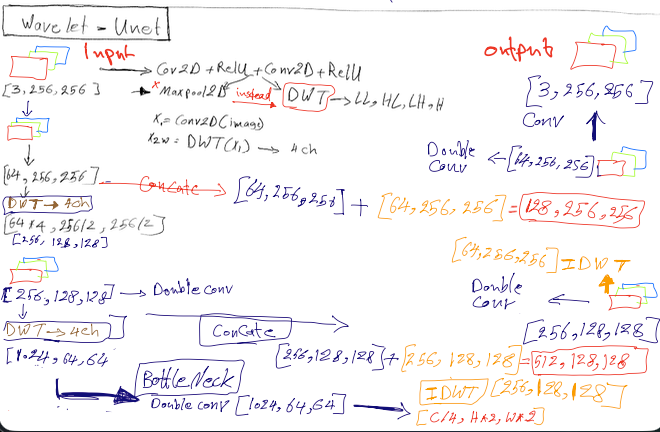

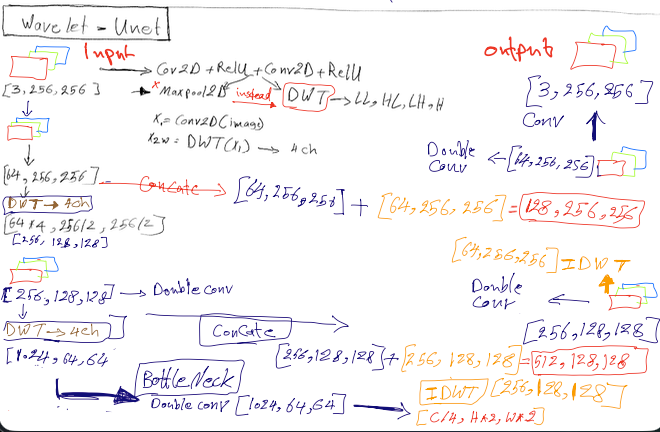

In [13]:
#Creating Wavelet Unet Model
class DoubleConv2D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels=in_ch, out_channels=out_ch, kernel_size=(3, 3), stride=1, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=out_ch, out_channels=out_ch, kernel_size=(3, 3), stride=1, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class PctBottleNeckHead(nn.Module):
    def __init__(self, in_ch=1024, cls=5):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=in_ch, out_features=256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(in_features=256, out_features=cls),
        )

    def forward(self, features):
        return self.fc(self.pool(features))


class DWT(nn.Module):
    """
    Haar Discrete Wavelet Transform implemented using conv2d.
    Produces 4 subbands (LL, LH, HL, HH) for each input channel.
    Output shape: [B, 4*C, H/2, W/2]
    """

    def __init__(self):
        super().__init__()

        # Haar filters (2x2)
        ll = torch.tensor([[0.5, 0.5],
                           [0.5, 0.5]])

        lh = torch.tensor([[0.5, 0.5],
                           [-0.5, -0.5]])

        hl = torch.tensor([[0.5, -0.5],
                           [0.5, -0.5]])

        hh = torch.tensor([[0.5, -0.5],
                           [-0.5, 0.5]])

        # Stack into shape [4, 1, 2, 2]
        filt = torch.stack([ll, lh, hl, hh], dim=0).unsqueeze(1)

        # Register as buffer so it moves with .to(device)
        self.register_buffer("filt", filt)

    def forward(self, x):
        """
        x: [B, C, H, W]
        returns: [B, 4*C, H/2, W/2]
        """
        B, C, H, W = x.shape

        # Repeat filters for each channel (grouped conv)
        # filt: [4,1,2,2] → [4*C, 1, 2, 2]
        weight = self.filt.repeat(C, 1, 1, 1)

        # Grouped convolution: each channel processed independently
        # Output: [B, 4*C, H/2, W/2]
        y = F.conv2d(x, weight, stride=2, groups=C)
        return y


class IDWT(nn.Module):
    """
    Inverse Haar Wavelet Transform implemented using conv_transpose2d.
    Input shape:  [B, 4*C, H, W]
    Output shape: [B, C,   2H, 2W]
    """

    def __init__(self):
        super().__init__()

        # Haar filters (same as DWT)
        ll = torch.tensor([[0.5, 0.5],
                           [0.5, 0.5]])

        lh = torch.tensor([[0.5, 0.5],
                           [-0.5, -0.5]])

        hl = torch.tensor([[0.5, -0.5],
                           [0.5, -0.5]])

        hh = torch.tensor([[0.5, -0.5],
                           [-0.5, 0.5]])

        filt = torch.stack([ll, lh, hl, hh], dim=0).unsqueeze(1)
        self.register_buffer("filt", filt)

    def forward(self, x):
        """
        x: [B, 4*C, H, W]
        returns: [B, C, 2H, 2W]
        """
        B, C4, H, W = x.shape
        C = C4 // 4

        # Repeat filters for each channel group
        weight = self.filt.repeat(C, 1, 1, 1)  # [4*C,1,2,2]

        # conv_transpose2d reconstructs the 2x upsampled signal
        y = F.conv_transpose2d(
            x,
            weight,
            stride=2,
            groups=C
        )

        # Output: [B, C, 2H, 2W]
        return y



class WaveletUnet(nn.Module):
    def _pct_map(self, pct, H, W):
        return pct[:, :, None, None].expand(-1, -1, H, W)

    def __init__(self, in_ch=3, out_ch=3, T=3.8, K=5):
        super().__init__()
        self.T = T # temperature scaling because the classifier is too accurate, logits returns almost one-hot encoded and we need havier vals

        self.d1 = DoubleConv2D(in_ch=in_ch, out_ch=64)  ## --> skip1
        self.dwt1 = DWT()

        self.d2 = DoubleConv2D(in_ch=256, out_ch=256)  ## --> skip2
        self.dwt2 = DWT()


        # bottleneck
        self.btn = DoubleConv2D(in_ch=1024, out_ch=1024)



        self.pct_head_d1  = PctBottleNeckHead(in_ch=64, cls=K)
        self.pct_head_d2  = PctBottleNeckHead(in_ch=256, cls=K)

        # classifier
        self.pct_head = PctBottleNeckHead(in_ch=1024, cls=K)

        # decoder
        self.idwt1 = IDWT()  ## --> skip2
        self.u1 = DoubleConv2D(in_ch=512 + K, out_ch=256)

        self.idwt2 = IDWT()  ## -->skip1
        self.u2 = DoubleConv2D(in_ch=128 + K, out_ch=64)

        self.out = nn.Conv2d(in_channels=64, out_channels=out_ch, stride=1, kernel_size=(1, 1))
        self.act = nn.Tanh()

    def forward(self, x, cls_tap="btn"):
        d1 = self.d1(x)
        dwt1 = self.dwt1(d1)

        d2 = self.d2(dwt1)
        dwt2 = self.dwt2(d2)

        btn = self.btn(dwt2)



        if cls_tap == "d1":
            logits = self.pct_head_d1(d1)
        elif cls_tap == "d2":
            logits = self.pct_head_d2(d2)
        else:
            logits = self.pct_head(btn)

        pct = torch.softmax(logits / self.T, dim=1)


        idwt1 = self.idwt1(btn)
        c1 = torch.cat([d2, idwt1], dim=1)
        c1 = torch.cat([c1, self._pct_map(pct, c1.shape[2], c1.shape[3])], dim=1)

        u1 = self.u1(c1)
        idwt2 = self.idwt2(u1)

        c2 = torch.cat([d1, idwt2], dim=1)
        c2 = torch.cat([c2, self._pct_map(pct, c2.shape[2], c2.shape[3])], dim=1)

        u2 = self.u2(c2)
        out = self.out(u2)
        act = self.act(out)
        return act, pct, logits


In [14]:
x = torch.randn(size=[2, 64, 256, 256])
DWT().forward(x)

tensor([[[[ 0.3068,  0.0356, -0.3232,  ...,  0.7075,  0.6401, -0.4970],
          [ 0.9940, -0.4106,  0.0611,  ...,  0.6821,  0.2130, -1.5522],
          [ 1.3032, -0.2342,  0.1361,  ..., -0.1010,  0.5168, -0.4334],
          ...,
          [-0.5459,  1.3803,  0.7375,  ..., -1.5693, -0.1633,  0.5540],
          [-0.8979,  0.8545,  1.1151,  ...,  1.2954, -1.5966,  1.5162],
          [ 0.3457,  0.9085, -0.2472,  ..., -0.0805,  1.4760,  0.1390]],

         [[ 0.2131,  0.1677,  1.7378,  ..., -2.0830, -0.9974, -0.1432],
          [-0.9396, -0.0484,  1.3512,  ...,  0.6464, -0.8804, -1.2444],
          [-0.4241, -2.1314,  1.2716,  ...,  1.1184,  1.6287, -1.2341],
          ...,
          [ 0.1755, -1.0348,  0.3366,  ..., -1.5721,  0.6830,  3.0481],
          [-0.5258, -1.0500, -1.6759,  ..., -0.3640, -1.5668, -0.8081],
          [-0.2943, -0.4008, -0.1109,  ...,  0.8378,  0.5903,  1.2490]],

         [[ 2.1193, -3.1751, -0.8500,  ..., -0.4590,  0.0081, -0.6339],
          [-1.4658, -3.0348,  

In [15]:
K = len(TASKS)
model_01_wavelet_unet = WaveletUnet(in_ch=3, out_ch=3, T=3.8, K=K)
model_01_wavelet_unet.state_dict()

OrderedDict([('d1.net.0.weight',
              tensor([[[[ 0.0585, -0.1309,  0.1116],
                        [-0.0579,  0.1501, -0.1228],
                        [-0.0860,  0.1319,  0.1061]],
              
                       [[ 0.0164, -0.1717,  0.0283],
                        [-0.0251,  0.0717, -0.1056],
                        [-0.0401, -0.0499, -0.0772]],
              
                       [[ 0.0842, -0.0552, -0.0552],
                        [-0.0647,  0.1602, -0.1894],
                        [ 0.0307,  0.0016,  0.1054]]],
              
              
                      [[[ 0.1072, -0.1614,  0.0126],
                        [-0.1493, -0.0872,  0.0938],
                        [-0.1776, -0.0513,  0.0552]],
              
                       [[ 0.1014,  0.1771, -0.0096],
                        [-0.0094, -0.0261, -0.0672],
                        [-0.1554,  0.0568, -0.0242]],
              
                       [[ 0.1018,  0.1459,  0.1261],
                       

In [16]:
summary(model_01_wavelet_unet, (3, 256, 256), device="cpu")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 256, 256]           1,792
       BatchNorm2d-2         [-1, 64, 256, 256]             128
              ReLU-3         [-1, 64, 256, 256]               0
            Conv2d-4         [-1, 64, 256, 256]          36,928
       BatchNorm2d-5         [-1, 64, 256, 256]             128
              ReLU-6         [-1, 64, 256, 256]               0
      DoubleConv2D-7         [-1, 64, 256, 256]               0
               DWT-8        [-1, 256, 128, 128]               0
            Conv2d-9        [-1, 256, 128, 128]         590,080
      BatchNorm2d-10        [-1, 256, 128, 128]             512
             ReLU-11        [-1, 256, 128, 128]               0
           Conv2d-12        [-1, 256, 128, 128]         590,080
      BatchNorm2d-13        [-1, 256, 128, 128]             512
             ReLU-14        [-1, 256, 1

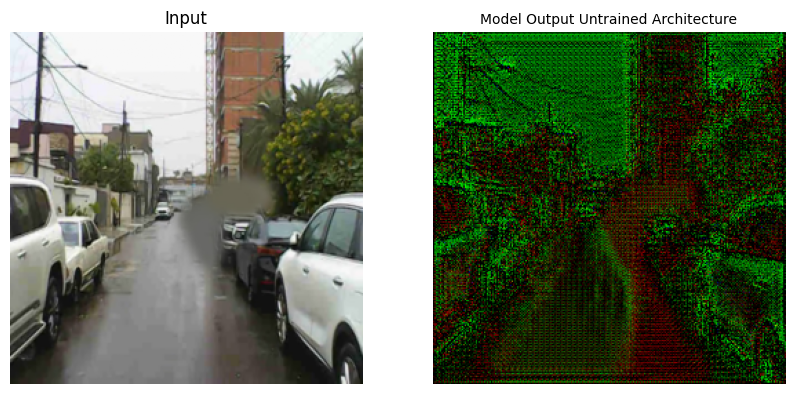

pct: tensor([[0.2053, 0.2005, 0.2013, 0.1904, 0.2024]]), cls_logits: tensor([[ 0.1101,  0.0212,  0.0363, -0.1753,  0.0570]])


In [17]:
x = next(iter(test_data))
ori_img = x[0]

with torch.no_grad():
    logits,pct, cls_logits = model_01_wavelet_unet(ori_img)

out_img = logits.squeeze().permute(1, 2, 0).detach().cpu().clamp(0, 1)
inp_img = ori_img.squeeze().permute(1, 2, 0).detach().cpu().clamp(0, 1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Input")
plt.imshow(inp_img.numpy())
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Model Output Untrained Architecture", fontsize=10)
plt.imshow(out_img)
plt.axis("off")
plt.show()

print(f"pct: {pct}, cls_logits: {cls_logits}")

In [18]:
optimizer = torch.optim.Adam(params=model_01_wavelet_unet.parameters(), lr=1e-3)
cls_loss_fn = nn.CrossEntropyLoss()

In [19]:
import torch.nn.functional as F
from pytorch_msssim import ssim


def grad_loss(pred, target):
    # calculate loss vertical and horizontal because changes in rains usually happens on edges so we take dx resulted from subtract right edges from left edges side, same for dy takes top to bottom. after that we calculate L1 loss absolute squared errors.

    pred_dx = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    pred_dy = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    tgt_dx = target[:, :, :, 1:] - target[:, :, :, :-1]
    tgt_dy = target[:, :, 1:, :] - target[:, :, :-1, :]
    return F.l1_loss(pred_dx, tgt_dx) + F.l1_loss(pred_dy, tgt_dy)


def tv_loss(x):
    #Total Variation Loss --> likes to make image more smooth and reduces noise, useful in night, rain streaks.
    # calculate dx absolute mean and dy absolute mean

    dx = x[:, :, :, 1:] - x[:, :, :, :-1]
    dy = x[:, :, 1:, :] - x[:, :, :-1, :]
    return (dx.abs().mean() + dy.abs().mean())


def contrast_loss(pred, target):
    # we calculate contrast loss, flatten(2) convert [B, C, H,W] --> [B, C, H with W] next calculate std for each one and std -> taking avg for each ch, the goal: fog usually reduces the contrast so we take std and subtract it from target std.
    pred_std = pred.flatten(2).std(dim=2).mean()
    tgt_std = target.flatten(2).std(dim=2).mean()
    return (pred_std - tgt_std).abs()


def ssim_loss(pred, target):
    ## structural similarity index measurement, calculate the similarity of the structure of frame. if SSIM high --> loss low, data_range 1.0
    # because we are not using normalization so pixels between 0 - 1
    return 1 - ssim(pred, target, data_range=1.0, size_average=True)


# here we defined the ids of each task
IDX_RAIN, IDX_GLARE, IDX_NIGHT, IDX_FOG, IDX_ROBS = 0, 1, 2, 3, 4


def loss_by_pct(pred, target, pct, cls_logits, cls_y):
    l1 = F.l1_loss(pred, target)
    s = ssim_loss(pred, target)

    ## merge similar distortions
    p_rain = (pct[:, IDX_RAIN] + pct[:, IDX_ROBS]).mean()
    p_fog = pct[:, IDX_FOG].mean()
    p_night = (pct[:, IDX_NIGHT] + pct[:, IDX_GLARE]).mean()

    ## losses function based on each distortion case
    g = grad_loss(pred, target)  ## for rain/rain_ob
    c = contrast_loss(pred, target)  ## fog
    tv = tv_loss(pred)  ## for night denoising
    img_loss = 0.88 * l1 + 0.12 * s + 0.20 * p_rain * g + 0.15 * p_fog * c + 0.05 * p_night * tv

    # classification loss
    cls_loss = cls_loss_fn(cls_logits, cls_y)
    cls_lambda = 0.5 #λ

    return img_loss + cls_lambda * cls_loss


ModuleNotFoundError: No module named 'pytorch_msssim'

In [20]:
from timeit import default_timer as timer
import torch
from torch import nn
from torch.utils.data import DataLoader


def train_step(model: nn.Module,
               dataloader: DataLoader,
               optimizer: torch.optim.Optimizer,
               loss_fn=loss_by_pct,
               device=device):
    total_loss, num_batches = 0.0, 0

    model.to(device)
    model.train()
    start_timer = timer()

    for batch, (X, y, cls_y) in enumerate(dataloader):
        X = X.to(device)
        y = y.to(device)
        cls_y = cls_y.to(device)

        # forward
        preds, pct, cls_logits = model(X)

        # loss
        loss = loss_fn(preds, y, pct.detach(), cls_logits, cls_y)

        # metrics
        batch_loss = loss.item()

        # backward
        optimizer.zero_grad(set_to_none=True)

        loss.backward()
        optimizer.step()

        total_loss += batch_loss
        num_batches += 1

        if batch % 10 == 0:
            print(f"Batch {batch}: loss={batch_loss:.4f}")

    # averages
    total_loss /= num_batches
    end_timer = timer()
    total_time = end_timer - start_timer

    print(f"Epoch Train --> loss_avg={total_loss:.4f} :: time={total_time:.2f}s")

    return {
        "loss": total_loss,
        "time": total_time
    }


In [21]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def psnr_tanh(pred, target, eps=1e-8):
    """
    pred, target: tensors in range [-1, 1]
    shape: [B,C,H,W] or [C,H,W]
    """

    # ensure batch dimension
    if pred.dim() == 3:
        pred = pred.unsqueeze(0)
        target = target.unsqueeze(0)

    # map from [-1,1] -> [0,1]
    pred_01 = (pred + 1.0) / 2.0
    target_01 = (target + 1.0) / 2.0

    pred_01 = pred_01.clamp(0.0, 1.0)
    target_01 = target_01.clamp(0.0, 1.0)

    mse = F.mse_loss(pred_01, target_01, reduction='none')  # [B,C,H,W]
    mse_per = mse.flatten(1).mean(dim=1)                     # [B]

    psnr_per = 10.0 * torch.log10(1.0 / (mse_per + eps))
    return psnr_per.mean().item(), psnr_per

In [22]:
def test_step(model: nn.Module,
              dataloader: DataLoader,
              loss_fn=loss_by_pct,
              device=device,
              validation=False):
    total_loss = 0.0
    total_psnr = 0.0
    total_ssim = 0.0
    action = "Validating" if validation else "Testing"
    start_timer = timer()
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for X, y, cls_y in dataloader:

            X = X.to(device)
            y = y.to(device)
            cls_y = cls_y.to(device)

            # forward
            preds, pct, cls_logits = model(X)
            psnr_mean, psnr_each = psnr_tanh(preds, y)
            s = ssim(preds, y, data_range=1.0, size_average=True)

            # loss
            loss = loss_fn(preds, y, pct.detach(), cls_logits, cls_y)

            # metrics
            batch_loss = loss.item()

            total_loss += batch_loss
            total_psnr += psnr_mean
            total_ssim += s.item()
            # print(f"{action} --> Loss: {loss:.2f} Acc: {acc:.2f}%")

    #calculate loss avg, accuracy avg
    total_loss /= len(dataloader)
    total_psnr /= len(dataloader)
    total_ssim /= len(dataloader)

    end_timer = timer()
    total_time = end_timer - start_timer
    print(f"Epoch {action} --> loss_avg={total_loss:.4f}, psnr_avg:{total_psnr:.2f}, ssim_avg:{total_ssim:.2f} :: time={total_time:.2f}s")

    return {
        "loss": total_loss,
        "psnr": total_psnr,
        "ssim": total_ssim,
        "time": total_time
    }

In [23]:
from tqdm import tqdm

training_steps = []
validation_steps = []

epochs = 200

for epoch in tqdm(range(epochs), colour="green"):
    # ----- Training -----
    train_metrics = train_step(
        model=model_01_wavelet_unet,
        dataloader=training_data,
        optimizer=optimizer,
        loss_fn=loss_by_pct,
        device=device
    )
    training_steps.append(train_metrics)

    # ----- Validation -----
    val_metrics = test_step(
        model=model_01_wavelet_unet,
        dataloader=val_data,
        loss_fn=loss_by_pct,
        device=device,
        validation=True
    )
    validation_steps.append(val_metrics)
    torch.save(model_01_wavelet_unet.state_dict(), "../models/adaptive_model_01_wavelet_unet_cls_btn_d1_d2.pth")

  0%|          | 0/200 [00:00<?, ?it/s]

Batch 0: loss=1.4285
Batch 10: loss=0.7716
Batch 20: loss=0.7941
Batch 30: loss=0.9937
Batch 40: loss=0.5791
Batch 50: loss=0.5001
Batch 60: loss=0.4360
Batch 70: loss=0.6989
Batch 80: loss=0.5799
Batch 90: loss=0.4609
Batch 100: loss=0.4913
Batch 110: loss=0.5234
Batch 120: loss=0.4959
Batch 130: loss=0.7689
Batch 140: loss=0.5164
Batch 150: loss=0.7269
Batch 160: loss=0.5082
Batch 170: loss=0.5507
Batch 180: loss=0.4653
Batch 190: loss=0.4637
Batch 200: loss=0.6477
Batch 210: loss=0.5932
Batch 220: loss=0.7259
Batch 230: loss=0.3800
Batch 240: loss=0.4333
Batch 250: loss=0.4541
Batch 260: loss=0.7125
Batch 270: loss=0.4505
Batch 280: loss=0.4674
Batch 290: loss=0.4625
Batch 300: loss=0.2224
Batch 310: loss=0.4018
Batch 320: loss=0.3800
Batch 330: loss=0.6993
Batch 340: loss=0.3869
Batch 350: loss=0.4893
Batch 360: loss=0.5181
Batch 370: loss=0.3914
Batch 380: loss=0.6737
Batch 390: loss=0.4981
Batch 400: loss=0.3937
Batch 410: loss=0.3287
Batch 420: loss=0.2793
Batch 430: loss=0.6698

  0%|          | 1/200 [04:54<16:16:39, 294.47s/it]

Epoch Validating --> loss_avg=0.5382, psnr_avg:27.97, ssim_avg:0.88 :: time=19.72s
Batch 0: loss=0.5537
Batch 10: loss=0.4401
Batch 20: loss=0.2471
Batch 30: loss=0.2597
Batch 40: loss=0.3423
Batch 50: loss=0.4291
Batch 60: loss=0.4932
Batch 70: loss=0.5497
Batch 80: loss=0.3767
Batch 90: loss=0.4243
Batch 100: loss=0.5857
Batch 110: loss=0.3846
Batch 120: loss=0.4336
Batch 130: loss=0.4636
Batch 140: loss=0.3227
Batch 150: loss=0.3709
Batch 160: loss=0.3551
Batch 170: loss=0.3231
Batch 180: loss=0.4554
Batch 190: loss=0.2690
Batch 200: loss=0.5135
Batch 210: loss=0.4292
Batch 220: loss=0.5194
Batch 230: loss=0.7504
Batch 240: loss=0.3920
Batch 250: loss=0.3597
Batch 260: loss=0.5818
Batch 270: loss=0.3931
Batch 280: loss=0.1979
Batch 290: loss=0.3964
Batch 300: loss=0.8259
Batch 310: loss=0.4955
Batch 320: loss=0.9096
Batch 330: loss=0.5938
Batch 340: loss=0.5398
Batch 350: loss=0.3391
Batch 360: loss=0.4761
Batch 370: loss=0.2557
Batch 380: loss=0.7952
Batch 390: loss=0.2872
Batch 40

  1%|          | 2/200 [09:48<16:11:21, 294.35s/it]

...

Epoch Validating --> loss_avg=0.0618, psnr_avg:42.81, ssim_avg:0.96 :: time=19.74s
Batch 0: loss=0.0278
Batch 10: loss=0.0262
Batch 20: loss=0.0100
Batch 30: loss=0.0676
Batch 40: loss=0.0287
Batch 50: loss=0.0325
Batch 60: loss=0.0090
Batch 70: loss=0.0218
Batch 80: loss=0.0198
Batch 90: loss=0.0090
Batch 100: loss=0.0270
Batch 110: loss=0.0194
Batch 120: loss=0.0166
Batch 130: loss=0.0112
Batch 140: loss=0.0099
Batch 150: loss=0.0206
Batch 160: loss=0.0188
Batch 170: loss=0.0292
Batch 180: loss=0.0204
Batch 190: loss=0.0157
Batch 200: loss=0.0099
Batch 210: loss=0.0127
Batch 220: loss=0.0149
Batch 230: loss=0.0079
Batch 240: loss=0.0096
Batch 250: loss=0.0162
Batch 260: loss=0.0331
Batch 270: loss=0.0180
Batch 280: loss=0.0173
Batch 290: loss=0.0147
Batch 300: loss=0.0140
Batch 310: loss=0.0273
Batch 320: loss=0.0151
Batch 330: loss=0.0345
Batch 340: loss=0.0230
Batch 350: loss=0.0336
Batch 360: loss=0.0129
Batch 370: loss=0.0084
Batch 380: loss=0.0194
Batch 390: loss=0.0292
Batch 40

100%|█████████▉| 199/200 [16:15:57<04:54, 294.14s/it]

Epoch Validating --> loss_avg=0.1152, psnr_avg:41.96, ssim_avg:0.96 :: time=19.75s
Batch 0: loss=0.0284
Batch 10: loss=0.0092
Batch 20: loss=0.0121
Batch 30: loss=0.0169
Batch 40: loss=0.0397
Batch 50: loss=0.0121
Batch 60: loss=0.0101
Batch 70: loss=0.0116
Batch 80: loss=0.0120
Batch 90: loss=0.0469
Batch 100: loss=0.0257
Batch 110: loss=0.0142
Batch 120: loss=0.0226
Batch 130: loss=0.0138
Batch 140: loss=0.0165
Batch 150: loss=0.0087
Batch 160: loss=0.0124
Batch 170: loss=0.0232
Batch 180: loss=0.0204
Batch 190: loss=0.0197
Batch 200: loss=0.0141
Batch 210: loss=0.0281
Batch 220: loss=0.0104
Batch 230: loss=0.0114
Batch 240: loss=0.0076
Batch 250: loss=0.0130
Batch 260: loss=0.0121
Batch 270: loss=0.0093
Batch 280: loss=0.0287
Batch 290: loss=0.0130
Batch 300: loss=0.0208
Batch 310: loss=0.0221
Batch 320: loss=0.0322
Batch 330: loss=0.0197
Batch 340: loss=0.0124
Batch 350: loss=0.0128
Batch 360: loss=0.0137
Batch 370: loss=0.0211
Batch 380: loss=0.0152
Batch 390: loss=0.0251
Batch 40

100%|██████████| 200/200 [16:20:51<00:00, 294.26s/it]

Epoch Validating --> loss_avg=0.0673, psnr_avg:43.33, ssim_avg:0.96 :: time=19.70s


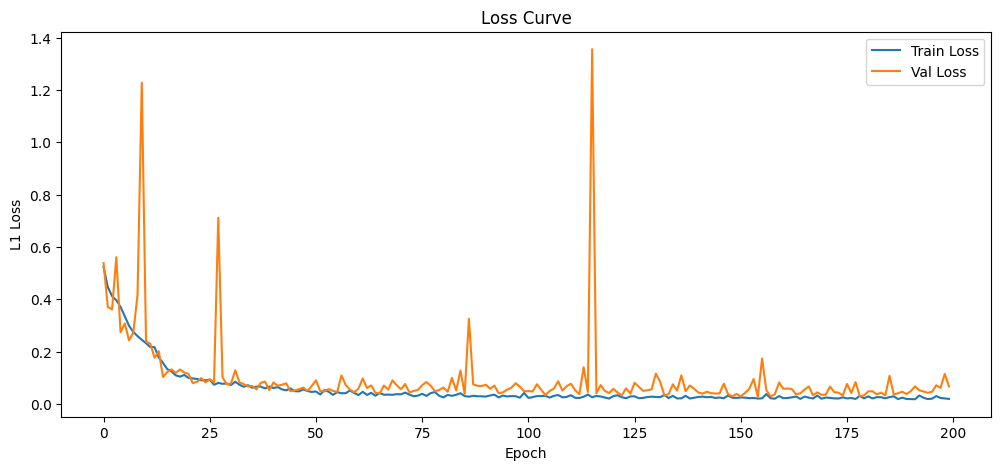

In [24]:
import matplotlib.pyplot as plt

train_loss = [r["loss"] for r in training_steps]
val_loss = [r["loss"] for r in validation_steps]

plt.figure(figsize=(12, 5))
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.legend()

In [25]:
dwt = DWT().to(device)
idwt = IDWT().to(device)

x = torch.randn(1, 3, 256, 256, device=device)  # random image
y = dwt(x)
xr = idwt(y)

diff = (x - xr).abs().max().item()
print("max |x - IDWT(DWT(x))| =", diff)

max |x - IDWT(DWT(x))| = 4.76837158203125e-07


In [26]:
unet_loaded_model = WaveletUnet(in_ch=3, out_ch=3, T=3.8, K=K)
unet_loaded_model.load_state_dict(torch.load(models_path / "adaptive_model_01_wavelet_unet_cls_btn_d1_d2.pth"))

<All keys matched successfully>

In [27]:
itr = iter(test_data)
device = "cuda"
unet_loaded_model.eval()
unet_loaded_model.to(device)

for i in range(90,120,1):
    X, y, cls_y = next(itr)
    X, y, cls_y = X.to(device), y.to(device), cls_y.to(device)
    o_img = X

    with torch.no_grad():
        preds, pct, cls_logits = unet_loaded_model(X)

    # # denormalize both
    # out_img = preds.squeeze().clamp(0.0, 1.0).permute(1, 2, 0).detach().cpu()
    # o_img = o_img.squeeze().clamp(0.0, 1.0).permute(1, 2, 0).detach().cpu()
    #
    # plt.figure(figsize=(10, 8))
    # plt.subplot(1, 2, 1)
    # plt.title("Input", fontsize=10)
    # plt.imshow(o_img)
    # plt.axis("off")
    #
    # plt.subplot(1, 2, 2)
    # plt.title("trained Wavelet-Unet Architecture Output", fontsize=10)
    # plt.imshow(out_img.numpy())
    # plt.axis("off")
    # plt.show()
    #
    # print(f"pct: {pct}, cls_logits: {cls_logits}")

In [28]:
test_step(model=unet_loaded_model,
        dataloader=test_data,
        loss_fn=loss_by_pct,
        device="cuda",
        validation=False)

Epoch Testing --> loss_avg=0.0473, psnr_avg:43.69, ssim_avg:0.97 :: time=45.53s


{'loss': 0.04728187532133984,
 'psnr': 43.69271876813698,
 'ssim': 0.9660422935642039,
 'time': 45.53480088399374}

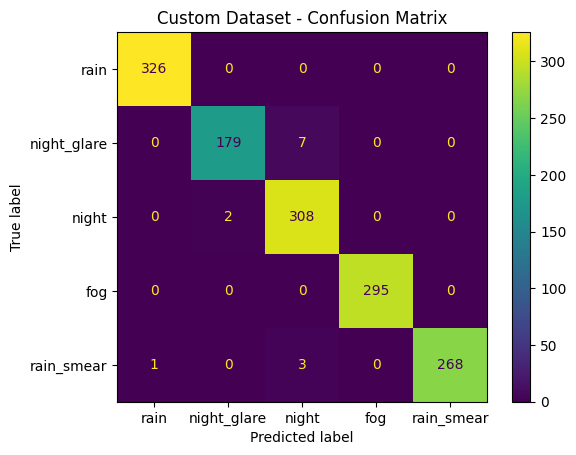

In [29]:
# confusion matrix
import torch
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

device = "cuda"
unet_loaded_model.eval().to(device)

all_gt = []
all_pred = []

with torch.no_grad():
    for X, y, cls_y in test_data:
        X = X.to(device)
        cls_y = cls_y.to(device)

        preds, pct, cls_logits = unet_loaded_model(X)

        # pred labels
        pred_lbl = cls_logits.argmax(dim=1)

        if cls_y.ndim > 1:
            gt_lbl = cls_y.argmax(dim=1)
        else:
            gt_lbl = cls_y

        all_gt.append(gt_lbl.detach().cpu())
        all_pred.append(pred_lbl.detach().cpu())

all_gt = torch.cat(all_gt).numpy()
all_pred = torch.cat(all_pred).numpy()

cm = confusion_matrix(all_gt, all_pred)

TASKS[-1] = "rain_smear"
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TASKS)
# plt.style.use("dark_background")
disp.plot(values_format="d")
plt.title("Custom Dataset - Confusion Matrix")
plt.show()


In [30]:
import torch
import torch.nn.functional as F
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

@torch.no_grad()
def eval_classification_metrics(model, dataloader, device="cuda", num_classes=None, class_names=None):
    model.eval()
    model.to(device)

    all_labels = []
    all_preds  = []
    all_probs  = []  # for ROC-AUC

    for batch in dataloader:
        X, _, cls_y = batch
        X = X.to(device, non_blocking=True)
        cls_y = cls_y.to(device, non_blocking=True)

        _, _, cls_logits = model(X)              # [B, C]
        probs = F.softmax(cls_logits, dim=1)     # [B, C]
        preds = torch.argmax(probs, dim=1)       # [B]

        all_labels.append(cls_y.detach().cpu())
        all_preds.append(preds.detach().cpu())
        all_probs.append(probs.detach().cpu())

    all_labels = torch.cat(all_labels).numpy()
    all_preds  = torch.cat(all_preds).numpy()
    all_probs  = torch.cat(all_probs).numpy()

    if num_classes is None:
        num_classes = all_probs.shape[1]

    # ---- Basic metrics ----
    acc = accuracy_score(all_labels, all_preds)

    prec_macro = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    rec_macro  = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1_macro   = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    prec_w = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    rec_w  = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1_w   = f1_score(all_labels, all_preds, average="weighted", zero_division=0)


    roc_auc = None
    try:
        roc_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
    except ValueError as e:
        roc_auc = f"ROC-AUC not computed: {e}"


    # ---- Optional report ----
    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names if class_names else None,
        zero_division=0
    )

    results = {
        "accuracy": acc,
        "precision_macro": prec_macro,
        "recall_macro": rec_macro,
        "f1_macro": f1_macro,
        "precision_weighted": prec_w,
        "recall_weighted": rec_w,
        "f1_weighted": f1_w,
        "roc_auc_ovr_macro": roc_auc,
        "classification_report": report,
    }

    return results


device = "cuda" if torch.cuda.is_available() else "cpu"


# class_names = ["rain", "fog", "lowlight", "snow", "clear"]
class_names = TASKS

results = eval_classification_metrics(
    model=unet_loaded_model,
    dataloader=test_data,
    device=device,
    num_classes=None,
    class_names=class_names
)

print("Accuracy:", results["accuracy"])
print("Precision (macro):", results["precision_macro"])
print("Recall (macro):", results["recall_macro"])
print("F1 (macro):", results["f1_macro"])
print("ROC-AUC (OVR, macro):", results["roc_auc_ovr_macro"])
print("\nReport:\n", results["classification_report"])

Accuracy: 0.9906407487401008
Precision (macro): 0.9908891262774111
Recall (macro): 0.9882416192283365
F1 (macro): 0.9894859516013452
ROC-AUC (OVR, macro): 0.9996936147331408

Report:
               precision    recall  f1-score   support

        rain       1.00      1.00      1.00       326
 night_glare       0.99      0.96      0.98       186
       night       0.97      0.99      0.98       310
         fog       1.00      1.00      1.00       295
  rain_smear       1.00      0.99      0.99       272

    accuracy                           0.99      1389
   macro avg       0.99      0.99      0.99      1389
weighted avg       0.99      0.99      0.99      1389



In [31]:
@torch.no_grad()
def eval_tap(model, loader, tap, device="cuda"):
    model.eval().to(device)
    y_true, y_pred = [], []
    for X, _, cls_y in loader:
        X, cls_y = X.to(device), cls_y.to(device)
        _, _, logits = model(X, cls_tap=tap)
        pred = logits.argmax(1)
        y_true.append(cls_y.cpu()); y_pred.append(pred.cpu())

    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()

    from sklearn.metrics import accuracy_score, f1_score
    return {
        "acc": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

for tap in ["d1", "d2", "btn"]:
    print(tap, eval_tap(unet_loaded_model, test_data, tap))

d1 {'acc': 0.25125989920806335, 'f1_macro': 0.137520746069905}
d2 {'acc': 0.265658747300216, 'f1_macro': 0.13318518826192602}
btn {'acc': 0.9906407487401008, 'f1_macro': 0.9894859516013452}


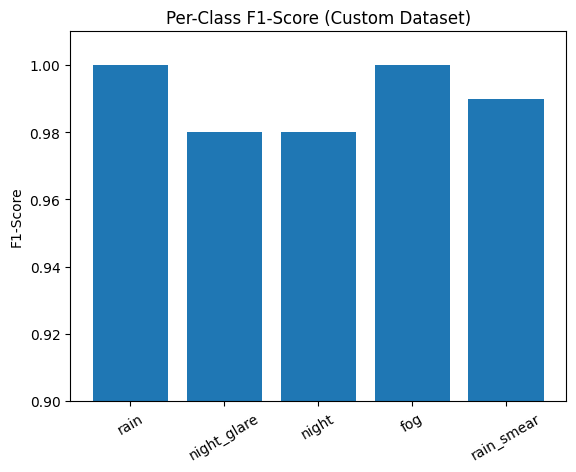

In [32]:
import matplotlib.pyplot as plt

classes = ["rain", "night_glare", "night", "fog", "rain_smear"]
f1_scores = [1.00, 0.98, 0.98, 1.00, 0.99]

plt.figure()
plt.bar(classes, f1_scores)
plt.ylim(0.9, 1.01)
plt.ylabel("F1-Score")
plt.title("Per-Class F1-Score (Custom Dataset)")
plt.xticks(rotation=30)
plt.show()